# Подготовка

In [1]:
# Установка дополнительных библиотек
!pip install Ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 9.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.optim as optim
from torch.nn import functional as F
from torchvision import transforms
from torchvision.utils import save_image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Загрузка StyleGAN2

In [5]:
# Клонирование репозитория StyleGAN2
!git clone https://github.com/rosinality/stylegan2-pytorch.git

Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 12.11 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [6]:
cd stylegan2-pytorch

/content/stylegan2-pytorch


In [7]:
from model import Generator

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Скачивание весов

In [8]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

In [9]:
cd ..

/content


Подгрузка весов

In [10]:
# Параметры генератора
size = 1024  # Размер изображения
latent_dim = 512  # Размер латентного пространства
n_mlp = 8  # Количество слоев MLP
channel_multiplier = 2
ckpt = '/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt'  # Путь к весам StyleGAN2

In [11]:
# Инициализация генератора
generator = Generator(size, latent_dim, n_mlp, channel_multiplier=channel_multiplier).to(device)
checkpoint = torch.load(ckpt)
generator.load_state_dict(checkpoint["g_ema"])  # Подгрузка весов
generator.eval()  # Режим валидации

<ipython-input-11-69a60cc14ec9>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt)


Generator(
  (style): Sequential(
    (0): PixelNorm()
    (1): EqualLinear(512, 512)
    (2): EqualLinear(512, 512)
    (3): EqualLinear(512, 512)
    (4): EqualLinear(512, 512)
    (5): EqualLinear(512, 512)
    (6): EqualLinear(512, 512)
    (7): EqualLinear(512, 512)
    (8): EqualLinear(512, 512)
  )
  (input): ConstantInput()
  (conv1): StyledConv(
    (conv): ModulatedConv2d(512, 512, 3, upsample=False, downsample=False)
    (noise): NoiseInjection()
    (activate): FusedLeakyReLU()
  )
  (to_rgb1): ToRGB(
    (conv): ModulatedConv2d(512, 3, 1, upsample=False, downsample=False)
  )
  (convs): ModuleList(
    (0): StyledConv(
      (conv): ModulatedConv2d(512, 512, 3, upsample=True, downsample=False)
      (noise): NoiseInjection()
      (activate): FusedLeakyReLU()
    )
    (1): StyledConv(
      (conv): ModulatedConv2d(512, 512, 3, upsample=False, downsample=False)
      (noise): NoiseInjection()
      (activate): FusedLeakyReLU()
    )
    (2): StyledConv(
      (conv): Modul

Тест генерации

/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.5.1+cu124. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


torch.Size([1, 3, 1024, 1024])


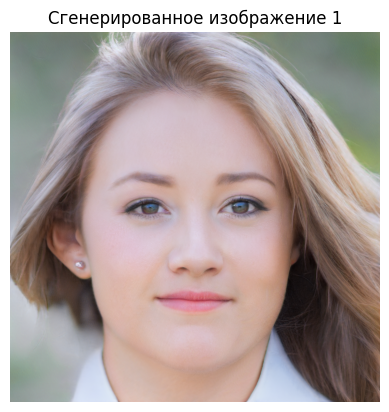

torch.Size([1, 3, 1024, 1024])


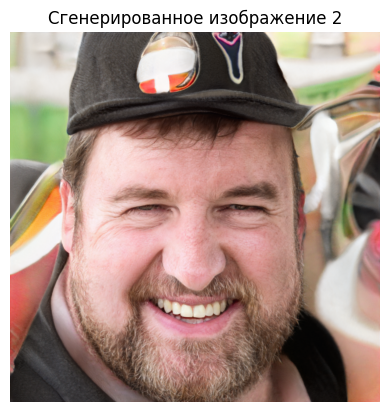

torch.Size([1, 3, 1024, 1024])


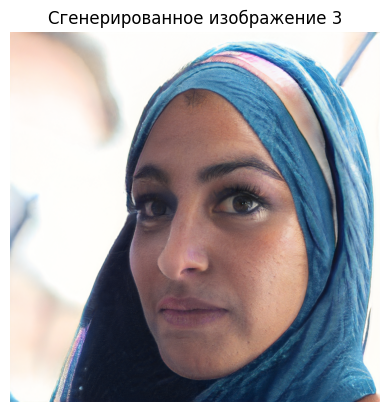

torch.Size([1, 3, 1024, 1024])


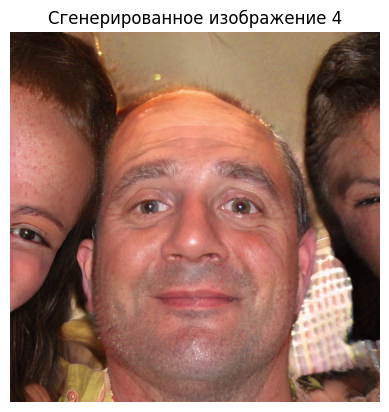

torch.Size([1, 3, 1024, 1024])


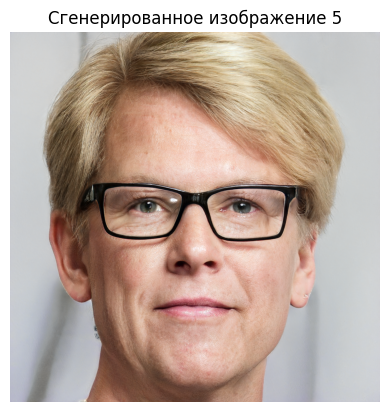

In [12]:
# Примеры генерации изображений
num_examples = 5  # Количество примеров для генерации

for i in range(num_examples):
    # Генерация случайного латентного вектора
    latent_z_example = torch.randn((1, latent_dim), device=device)
    generated_img_example, _ = generator([latent_z_example], input_is_latent=False)
    print(generated_img_example.shape)
    # Визуализация сгенерированного изображения
    plt.imshow((generated_img_example.clip(-1,1).cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
    plt.title(f"Сгенерированное изображение {i + 1}")
    plt.axis('off')
    plt.show()

## Загрузка изображения

Загрузка и подготовка реального изображения

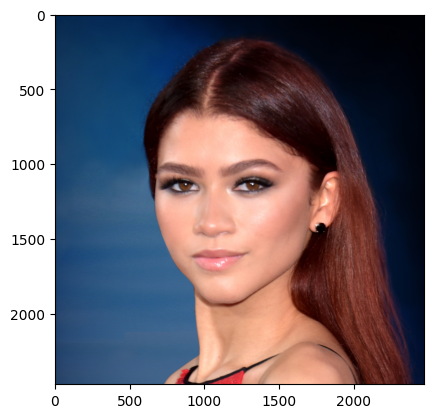

In [13]:
from PIL import Image
image_path = '/content/drive/MyDrive/Colab Notebooks/Faces Text Editing/zendaya.jpg'  # Путь к изображению
plt.imshow(Image.open(image_path))
plt.show()

## Выравнивание

Этот StyleGAN2 обучался на датасете FFHQ, где лица были выровнены перед обучением

In [14]:
!git clone https://github.com/omertov/encoder4editing.git

Cloning into 'encoder4editing'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 172 (delta 49), reused 42 (delta 42), pack-reused 94 (from 1)
Receiving objects: 100% (172/172), 33.43 MiB | 16.29 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [15]:
cd encoder4editing

/content/encoder4editing


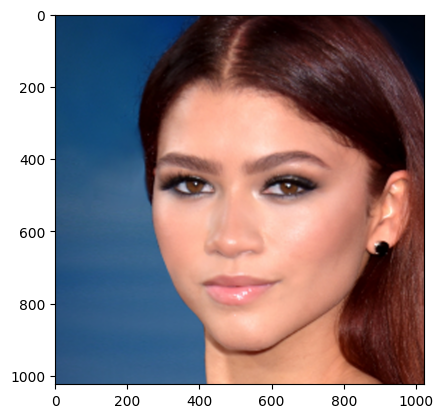

In [16]:
import dlib
from utils.alignment import align_face

import packaging.version
if packaging.version.parse(Image.__version__) >= packaging.version.parse('10.0.0'):
    Image.ANTIALIAS=Image.LANCZOS

def run_alignment(image_path, transform_size):
    predictor = dlib.shape_predictor("/content/drive/MyDrive/Colab Notebooks/Faces Text Editing/shape_predictor_68_face_landmarks.dat")
    aligned_image = align_face(filepath=image_path, predictor=predictor)
    if aligned_image.size != transform_size:
        aligned_image = cv2.resize(np.array(aligned_image), transform_size, interpolation=cv2.INTER_CUBIC)
    return aligned_image

resize_dims = (1024, 1024)
aligned_image = run_alignment(image_path, resize_dims)
plt.imshow(aligned_image)
plt.show()

# Инверсия

## Предобученный энкодер

In [17]:
# Импортируем необходимые библиотеки
from models.psp import pSp  # Импортируем модель pSp
from argparse import Namespace


/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

ids = ['1cUv_reLE6k3604or78EranS7XzuVMWeO']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

In [20]:
def build_net(model_path):
    ckpt = torch.load(model_path, map_location=device, weights_only=True)
    opts = ckpt['opts']
    print(opts)
    opts['checkpoint_path'] = model_path

    opts = Namespace(**opts)

    net = pSp(opts).to(device)
    net.load_state_dict(ckpt['state_dict'], strict=True)
    net.eval()

    return net, opts

net_path = '/content/encoder4editing/e4e_ffhq_encode.pt'  # Путь к весам энкодера
net, opts = build_net(net_path)

{'exp_dir': None, 'dataset_type': 'ffhq_encode', 'encoder_type': 'Encoder4Editing', 'batch_size': 8, 'test_batch_size': 4, 'workers': 8, 'test_workers': 4, 'learning_rate': 0.0001, 'optim_name': 'ranger', 'train_decoder': False, 'start_from_latent_avg': True, 'lpips_lambda': 0.8, 'id_lambda': 0.1, 'l2_lambda': 1.0, 'stylegan_weights': '', 'stylegan_size': 1024, 'checkpoint_path': None, 'max_steps': 300000, 'image_interval': 100, 'board_interval': 50, 'val_interval': 10000, 'save_interval': 200000, 'w_discriminator_lambda': 0.1, 'w_discriminator_lr': 2e-05, 'r1': 10, 'd_reg_every': 16, 'use_w_pool': True, 'w_pool_size': 50, 'sub_exp_dir': None, 'delta_norm': 2, 'delta_norm_lambda': 0.0002, 'keep_optimizer': False, 'resume_training_from_ckpt': None, 'update_param_list': None, 'device': 'cuda:0', 'lpips_type': 'alex', 'progressive_steps': [0, 20000, 22000, 24000, 26000, 28000, 30000, 32000, 34000, 36000, 38000, 40000, 42000, 44000, 46000, 48000, 50000, 52000], 'progressive_start': 20000, 

/content/encoder4editing/models/psp.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(self.opts.checkpoint_path, map_location='cpu')


In [21]:
def invert_image_with_net(aligned_img_np, net, opts):
    # Если модель обучена на 256×256, то нужно сделать resize
    aligned_img_pil = Image.fromarray(aligned_img_np)

    input_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    in_tensor = input_transform(aligned_img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        images, latents = net(in_tensor, randomize_noise=False, return_latents=True)

    img_np = images[0].cpu().detach().numpy()  # shape: (3, H, W)
    img_np = np.transpose(img_np, (1, 2, 0))   # -> (H, W, 3)

    img_resized = cv2.resize(img_np, (resize_dims[0], resize_dims[1]), interpolation=cv2.INTER_CUBIC)

    img_resized_t = np.transpose(img_resized, (2, 0, 1))  # (3, newH, newW)
    img_resized_t = torch.from_numpy(img_resized_t).unsqueeze(0).float().to(device)  # [1, 3, newH, newW]

    images = img_resized_t
    return images, latents


image, w_plus_code = invert_image_with_net(aligned_image, net, opts)
print(image[0].shape)
# или если out == [images, latents], то images иногда список
# image = image[-1].unsqueeze(0)
# w_plus_code = w_plus_code[-1].unsqueeze(0)
print("Полученный w+:", w_plus_code.shape)

torch.Size([3, 1024, 1024])
Полученный w+: torch.Size([1, 18, 512])


Посмотрим на пары реальное изображение - инвертированное

## Дополнительная инверсия (шумовая регуляризация)

In [23]:
file_path = "/content/stylegan2-pytorch/lpips/__init__.py"

# Откроем файл и прочитаем его содержимое
with open(file_path, 'r') as file:
    lines = file.readlines()

# Заменим нужную строку
with open(file_path, 'w') as file:
    for line in lines:
        # Если в строке есть "compare_ssim", заменим на "structural_similarity"
        if "from skimage.measure import compare_ssim" in line:
            file.write("from skimage.metrics import structural_similarity\n")
        else:
            file.write(line)

print("Замена выполнена успешно!")

Замена выполнена успешно!


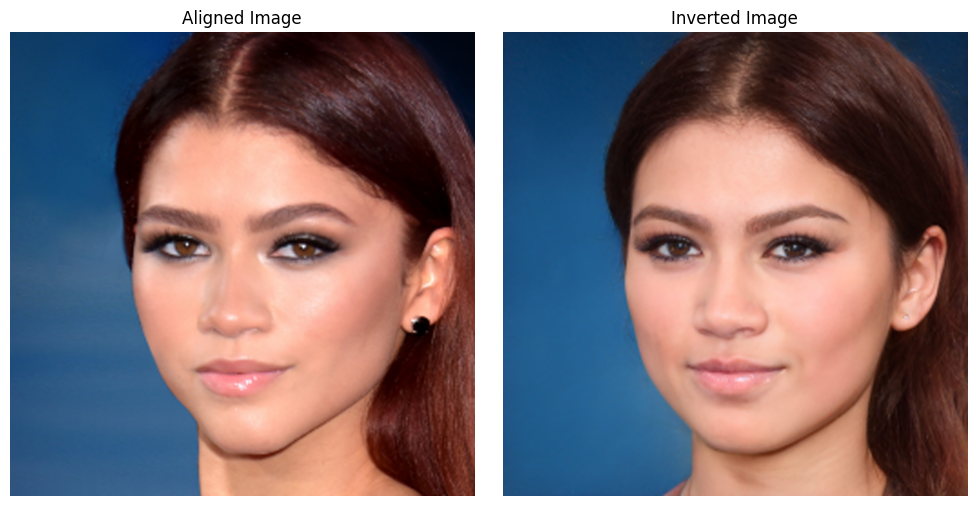

In [22]:
%matplotlib inline
from utils.common import tensor2im

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(aligned_image)
plt.title('Aligned Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# inverted_image_np = image.cpu().detach()[0].permute(1, 2, 0).numpy()
# inverted_image_np = (inverted_image_np.clip(-1, 1) + 1) / 2
plt.imshow(tensor2im(image[0]))
plt.title('Inverted Image')
plt.axis('off')

plt.tight_layout()
plt.show()

In [24]:
cd ../stylegan2-pytorch/

/content/stylegan2-pytorch


In [25]:
import lpips  # Библиотека для вычисления perceptual loss

In [26]:
cd ..

/content


In [27]:
def get_lr(t, initial_lr, rampdown=0.25, rampup=0.05):
    lr_ramp = min(1, (1 - t) / rampdown)
    lr_ramp = 0.5 - 0.5 * math.cos(lr_ramp * math.pi)
    lr_ramp = lr_ramp * min(1, t / rampup)
    return initial_lr * lr_ramp


def noise_regularize(noises):
    """
    Функция для регуляризации шума.
    Вычисляет лосс на основе шума, чтобы уменьшить его влияние на генерацию.

    Параметры:
    noises (list): Список тензоров шума.

    Возвращает:
    loss (float): Общая потеря, связанная с шумом.
    """
    loss = 0  # Инициализация потерь

    for noise in noises:  # Проход по каждому шуму в списке
        size = noise.shape[2]

        while True:  # Цикл для уменьшения размера шума
            # Вычисление лосса на основе свертки шума с его сдвинутой версией
            loss = (
                loss
                + (noise * torch.roll(noise, shifts=1, dims=3)).mean().pow(2)  # Сдвиг по ширине
                + (noise * torch.roll(noise, shifts=1, dims=2)).mean().pow(2)  # Сдвиг по высоте
            )

            if size <= 8:
                break

            # Уменьшение размера шума вдвое
            noise = noise.reshape([-1, 1, size // 2, 2, size // 2, 2])
            noise = noise.mean([3, 5])
            size //= 2

    return loss


def noise_normalize_(noises):
    """
    Нормализация шума.
    Приводит шум к нулевому среднему и единичной дисперсии.

    Параметры:
    noises (list): Список тензоров шума.
    """
    for noise in noises:
        mean = noise.mean()  # Вычисление среднего значения
        std = noise.std()  # Вычисление стандартного отклонения

        # Нормализация: вычитание среднего и деление на стандартное отклонение
        noise.data.add_(-mean).div_(std)


def latent_noise(latent, strength):
    """
    Добавление шума к латентному вектору.
    Генерирует случайный шум и добавляет его к латентному вектору.

    Параметры:
    latent (Tensor): Латентный вектор.
    strength (float): Сила добавляемого шума.

    Возвращает:
    Tensor: Латентный вектор с добавленным шумом.
    """
    noise = torch.randn_like(latent) * strength

    return latent + noise

In [28]:
transform_to_neg1_1 = transforms.Compose([
    transforms.ToTensor(),  # -> [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # теперь -> [-1,1]
])

aligned_image_tensor = transform_to_neg1_1(aligned_image).unsqueeze(0).to(device)
# aligned_image_tensor = transforms.ToTensor()(aligned_image).unsqueeze(0).to(device)

In [35]:
latent_w = w_plus_code.clone().to(device)

latent_mean = latent_w.mean(dim=0, keepdim=True)
latent_std = ((latent_w - latent_mean) ** 2).mean().sqrt()
print("Std of w+:", latent_std.item())

latent_in = latent_w.detach().clone()#.repeat(1, generator.n_latent, 1)
latent_in.requires_grad = True
print(latent_in.shape)

Std of w+: 0.0
torch.Size([1, 18, 512])


In [36]:
noises_single = generator.make_noise()
noises = []
for noise in noises_single:
    noises.append(noise.repeat(1, 1, 1, 1).normal_())
    noises[-1].requires_grad = True

In [37]:
num_steps_w = 1000  # Количество шагов оптимизации в W-пространстве
alpha = 5  # Коэффициент для перцептивной потери
beta = 1e5 # Коэффициент для шумовой потери

init_lr = 0.01
optimizer_w = optim.Adam([latent_in] + noises, lr=init_lr)  # Оптимизатор для инверсии в W-пространстве
# scheduler_w = torch.optim.lr_scheduler.ExponentialLR(optimizer_w, gamma=0.99)  # Плавное снижение скорости обучения
mse = torch.nn.MSELoss()
perceptual_loss = lpips.PerceptualLoss(model="net-lin", net="alex", use_gpu=device)

losses = {
    'mse': [],
    'lpips': [],
    'noise_reg': [],
    'all': []
}


# Инверсия в W-пространстве с шумовой регуляризацией
for step in range(num_steps_w):
    torch.cuda.empty_cache()
    t = step / num_steps_w
    lr = get_lr(t, init_lr)
    optimizer_w.param_groups[0]["lr"] = lr
    optimizer_w.zero_grad()  # Обнуление градиентов перед новой итерацией

    noise_strength = latent_std * 0.05 * max(0, 1 - t / 0.75) ** 2
    latent_n = latent_noise(latent_in, noise_strength.item())

    generated_img, _ = generator([latent_n], input_is_latent=True, noise=noises)  # Генерация изображения из W-вектора

    # Основные потери
    noise_loss = noise_regularize(noises)
    mse_loss = mse(generated_img, aligned_image_tensor)  # Вычисление потерь MSE
    lpips_loss = perceptual_loss(generated_img, aligned_image_tensor).mean()  # Вычисление перцептивной потери
    # noise_reg_loss = noise_regularize(noises) * noise_strength  # (опционально) Шумовая регуляризация

    # Суммарные потери
    loss = mse_loss + alpha * lpips_loss + beta * noise_loss
    loss.backward()  # Обратное распространение ошибки

    optimizer_w.step()  # Обновление параметров W-вектора

    noise_normalize_(noises)

    losses['mse'].append(mse_loss.item())
    losses['lpips'].append(lpips_loss.item())
    losses['noise_reg'].append(noise_loss.item())
    losses['all'].append(loss.item())

    if step % 50 == 0 or step + 1 == num_steps_w:  # Каждые 50 шагов
        print(f"inversion_generated_w/Step [{step}/{num_steps_w}], Loss: {loss.item():.4f}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((aligned_image_tensor.cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей

        plt.show()  # Отображение графиков
        if step + 1 == num_steps_w:
            save_image(generated_img, f"z_inversion_final.png")  # Сохранение сгенерированного изображения

print("Инверсия в W-пространстве с регуляризацией шумов завершена.")  # Сообщение о завершении процесса

Output hidden; open in https://colab.research.google.com to view.

# Оптимизация

- Отредактированное изображение соответствует текстовому запросу

- Сохраняет identity изначального человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$


## Clip Loss

$D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами CLIP для двух аргументов.

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)) \cdot E_{\text{CLIP}}(t) \rangle }{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$

In [38]:
# Установка зависимостей
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-_hb9m54o
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-_hb9m54o
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [44]:
# Загрузим нашу модель ArcFace
model_path = "/content/model_ir_se50.pth"
id_loss = IDLoss(model_path, device)

<ipython-input-42-1c24f58563a1>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.facenet.load_state_dict(torch.load(model_weights)) # , map_location=device, weights_onl

In [39]:
import clip

class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP (Contrastive Language–Image Pre-training).
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024):
        """
        Инициализирует класс CLIPLoss.

        Args:
            opts: Объект, содержащий различные параметры, включая размер изображения StyleGAN.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию предварительной обработки
        self.model, self.preprocess = clip.load("ViT-B/32", device=device) # Картинки 224x224

        self.image_transform = torch.nn.Sequential(
            torch.nn.AdaptiveAvgPool2d((224, 224))  # Приводим изображение к размеру 224x224
        )

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом.

        Args:
            image: Входной тензор изображения.
            text: Тензор текстового описания.

        Returns:
            Значение потерь CLIP.
        """
        # Меняем размерность изображения для получения нужного разрешения для CLIP
        image = self.image_transform(image)

        image = (image + 1) / 2

        # Нормализация и извлечение эмбеддингов для изображения и текста
        image_features = self.model.encode_image(image)
        text_features = self.model.encode_text(text)

        # Нормализация эмбеддингов для вычисления косинусного расстояния
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Сходство: косинусное расстояние (чем ближе к 1, тем больше сходство)
        similarity = torch.cosine_similarity(image_features, text_features)

        # Потери = 1 - сходство (чтобы минимизация потерь приводила к увеличению сходства)
        loss = 1 - similarity.mean()

        return loss

In [40]:
clip_loss = CLIPLoss()

100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 45.4MiB/s]


## Id Loss

Для сохранения identity человека используется специально предобученную модель [ArcFace](https://arxiv.org/abs/1801.07698), которая по фотографии вычисляет некоторые характерные для человека embedding вектора. Затем нам необходимо посчитать косинусное расстояние между ожидаемым embedding вектором и тем, что получается в процессе оптимизации, при этом без нормировки:

$$ L_{\text{ID}}(w) = 1 - \langle R(G(w_s)), R(G(w)) \rangle $$

Подгрузка [модели](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py)

In [41]:
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model

Функция потерь

In [42]:
class IDLoss(torch.nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        # Загружаем предобученную модель ResNet ArcFace для извлечения признаков лица.
        # input_size: размер входного изображения (112x112).
        self.facenet = Backbone(input_size=112, num_layers=50, drop_ratio=0.6, mode='ir_se')
        # Загружаем веса предобученной модели
        self.facenet.load_state_dict(torch.load(model_weights)) # , map_location=device, weights_only=True
        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        # Перемещаем модель ArcFace на GPU, если доступен.
        self.facenet.to(device)


    def extract_feats(self, x):
        # Функция для извлечения эмбеддингов лица из изображения x.
        # Если размер изображения не 256x256, изменяем его с помощью пулинга.
        if x.shape[2] != 256:
            x = self.pool(x)
        # Обрезаем центральную область изображения (35:223, 32:220), содержащую лицо.
        x = x[:, :, 35:223, 32:220]
        # Изменяем размер обрезанной области до 112x112 с помощью пулинга.
        x = self.face_pool(x)
        # Извлекаем эмбеддинги лица с помощью модели ArcFace.
        x_feats = self.facenet(x)
        # Возвращаем извлеченные эмбеддинги.
        return x_feats

    def forward(self, y_hat, y):
        # Функция для вычисления ID Loss.
        # y_hat: отредактированное изображение.
        # y: исходное изображение.

        n_samples = y.shape[0]

        # Извлекаем признаки лица из исходного изображения.
        y_feats = self.extract_feats(y)

        # Извлекаем признаки лица из отредактированного изображения.
        y_hat_feats = self.extract_feats(y_hat)

        # Не забудьте сделать detach()!
        y_feats = y_feats.detach()

        # Считаем наш лосс
        similarity = torch.cosine_similarity(y_feats, y_hat_feats, dim=1)
        loss = 1 - similarity.mean()
        return loss

In [43]:
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

ids = ['1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

## Генерация

In [63]:
prompt = "woman with dark black skin"
text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)

In [72]:
latent = latent_in.detach().clone()
latent.requires_grad = True
target_image = aligned_image_tensor
# target_image = transforms.ToTensor()(aligned_image).unsqueeze(0).to(device)

optimizer = torch.optim.Adam([latent], lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

num_steps = 200  # количество шагов оптимизации
l2_lambda = 0.01  # коэффициент для L2 регуляризации
id_lambda = 0.05  # коэффициент для identity loss

losses_opt = {'id': [],
          'l2': [],
          'clip': [],
          'all': []
          }

In [73]:
latent.shape

torch.Size([1, 18, 512])

In [74]:
for step in range(num_steps):
    torch.cuda.empty_cache()
    optimizer.zero_grad()
    image_gen, _ = generator([latent], input_is_latent=True, randomize_noise=False)

    clip_loss_val = clip_loss(image_gen, text_inputs)
    l2_loss_val = torch.sum((latent - latent_in) ** 2)
    id_loss_val = id_loss(image_gen, target_image)
    loss = clip_loss_val + l2_lambda * l2_loss_val + id_lambda * id_loss_val

    losses_opt['id'].append(id_loss_val.cpu().detach().numpy())
    losses_opt['l2'].append(l2_loss_val.cpu().detach().numpy())
    losses_opt['clip'].append(clip_loss_val.cpu().detach().numpy())
    losses_opt['all'].append(loss.cpu().detach().numpy())
    # print(losses_opt['clip'][-1], losses_opt['l2'][-1], losses_opt['id'][-1])
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Визуализация и вывод потерь
    if step % 50 == 0 or step == num_steps - 1:
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {losses_opt['all'][-1]}")
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))

        axs[0].imshow((image_gen.cpu().detach()[0].permute(1, 2, 0).clip(-1, 1) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")
        axs[0].axis('off')

        axs[1].imshow((target_image.cpu().detach()[0].permute(1, 2, 0).clip(-1, 1) + 1) / 2)
        axs[1].set_title("Целевое изображение")
        axs[1].axis('off')
        plt.show()

        if step + 1 == num_steps:
            save_image(image_gen, f"edited_image.png")  # Сохранение сгенерированного изображения

Output hidden; open in https://colab.research.google.com to view.

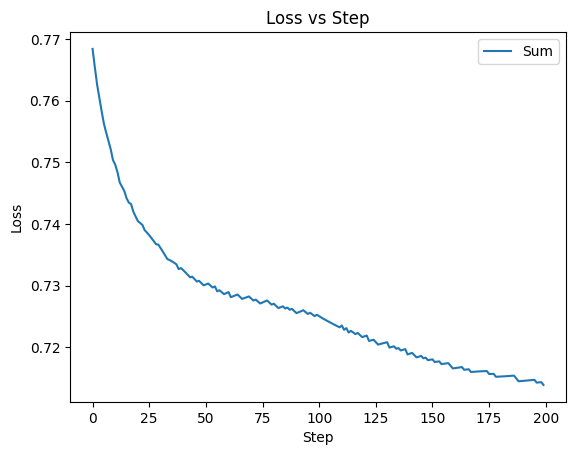

In [75]:
plt.plot(losses_opt['all'], label='Sum')
plt.title("Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

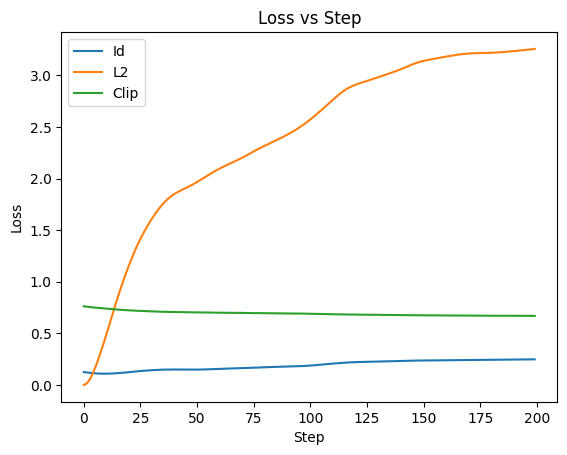

In [76]:
plt.plot(losses_opt['id'], label='Id')
plt.plot(losses_opt['l2'], label='L2')
plt.plot(losses_opt['clip'], label='Clip')
plt.title("Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()